# Portfolio Assessment 1: Exploratory Data Analysis (EDA) & Data Preparation

Course: COS40007 - AI Engineering  
Student Name: Le Mai Chi  
Student ID: 105555880 <br>
Data Name: NASA Battery Dataset <br> 
Data Source: https://www.kaggle.com/datasets/patrickfleith/nasa-battery-dataset


## Imports, Format

Load the necessary libraries and modify the output format

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# format for convenient loading
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:3f}")

In [3]:
# load metadata.csv
candidates = list(Path("../dataset/").rglob("metadata.csv"))

valid = [p for p in candidates if (p.parent / "data").exists()]
if not valid:
    raise FileNotFoundError("Could not find metadata.csv.")

META_PATH = valid[0]
DATA_DIR = META_PATH.parent / "data"

OUTPUT_DIR = Path("../output")

FEATURE_PATH = OUTPUT_DIR / "battery_discharge_features.csv"
CLEAN_DATA_PATH = OUTPUT_DIR / "nasa_battery_eda_clean.csv"

# print("Metadata:", META_PATH)
# print("Data folder:", DATA_DIR)
# print("Output folder:", OUTPUT_DIR)

**Data source note:** The Kaggle author converted the original NASA `.mat` files into CSV format for easier access. The CSV files are stored in `dataset/`. The underlying measurements still come from the original NASA experiments.<br>
<br>
Original data source: https://www.kaggle.com/datasets/patrickfleith/nasa-randomized-battery-usage-dataset 

In [4]:
FIG_DIR = Path("../output/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Task 1: Dataset Loading & Initial Exploration

The metadata contains charge, discharge and impedance experiments. Since `Capacity` is the target of interest and belongs to discharge experiments, only discharge cycles are used to construct the analytical dataset.


In [5]:
meta = pd.read_csv(META_PATH, dtype={"filename": str})

# Convert expected numerical columns
for col in ["ambient_temperature", "test_id", "uid", "Capacity", "Re", "Rct"]:
    if col in meta.columns:
        meta[col] = pd.to_numeric(meta[col], errors="coerce")

print("Metadata shape:", meta.shape)
print("Number of batteries:", meta["battery_id"].nunique())

display(meta.head(5))

Metadata shape: (7565, 10)
Number of batteries: 34


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.056058,0.200970
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.053192,0.164734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN


In [6]:
meta.info()

<class 'pandas.DataFrame'>
RangeIndex: 7565 entries, 0 to 7564
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   type                 7565 non-null   str    
 1   start_time           7565 non-null   str    
 2   ambient_temperature  7565 non-null   int64  
 3   battery_id           7565 non-null   str    
 4   test_id              7565 non-null   int64  
 5   uid                  7565 non-null   int64  
 6   filename             7565 non-null   str    
 7   Capacity             2769 non-null   float64
 8   Re                   1947 non-null   float64
 9   Rct                  1947 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 591.1 KB


In [7]:
display(meta["type"].value_counts().to_frame("count"))

,count
type,
charge,2815
discharge,2794
impedance,1956


charge > discharge > impedance

Each discharge CSV is a time-series experiment rather than one machine-learning row. I therefore summarise each file into cycle-level voltage, current, temperature, load and duration features so that each discharge experiment becomes one observation.

In [8]:
discharge_meta = (
    meta.loc[meta["type"].eq("discharge")]
        .copy()
        .sort_values(["battery_id", "test_id"])
        .reset_index(drop=True)
)

print("Discharge experiments:", len(discharge_meta))
print("Capacity available:", discharge_meta["Capacity"].notna().sum())
print("Capacity missing:", discharge_meta["Capacity"].isna().sum())

Discharge experiments: 2794
Capacity available: 2769
Capacity missing: 25


Each discharge CSV contains time-series measurements recorded during a battery discharge cycle. The selected columns capture the main electrical, thermal, load, and time characteristics needed for feature engineering.

In [9]:
SENSOR_COLS = [
    "Voltage_measured",
    "Current_measured",
    "Temperature_measured",
    "Current_load",
    "Voltage_load",
    "Time",
]

def extract_discharge_features(file_path):
    x = pd.read_csv(file_path)

    available = [c for c in SENSOR_COLS if c in x.columns]
    x = x[available].copy()

    for col in available:
        x[col] = pd.to_numeric(x[col], errors="coerce")

    if "Time" in x.columns:
        x = x.sort_values("Time")

    features: dict[str, object] = {"n_samples": len(x)}
    # Time
    if "Time" in x.columns:
        features["discharge_duration_s"] = (
            x["Time"].max() - x["Time"].min()
        )

    # Voltage
    if "Voltage_measured" in x.columns:
        v = x["Voltage_measured"].dropna()

        features["mean_voltage"] = v.mean()
        features["min_voltage"] = v.min()
        features["max_voltage"] = v.max()
        features["voltage_std"] = v.std()
        features["voltage_drop"] = (
            v.iloc[0] - v.iloc[-1] if len(v) >= 2 else np.nan
        )

    # Current
    if "Current_measured" in x.columns:
        current = x["Current_measured"].dropna()

        features["mean_abs_current"] = current.abs().mean()
        features["max_abs_current"] = current.abs().max()
        features["current_std"] = current.std()

    # Temperature
    if "Temperature_measured" in x.columns:
        temp = x["Temperature_measured"].dropna()

        features["mean_temperature"] = temp.mean()
        features["max_temperature"] = temp.max()
        features["temperature_rise"] = (
            temp.max() - temp.iloc[0]
            if len(temp) >= 1 else np.nan
        )

    # Load
    if "Current_load" in x.columns:
        features["mean_abs_load_current"] = (
            x["Current_load"].abs().mean()
        )

    if "Voltage_load" in x.columns:
        features["mean_load_voltage"] = x["Voltage_load"].mean()

    return features

Each discharge file is converted into one row of engineered features and combined with its battery metadata. The resulting table is saved locally so it can be loaded directly on later runs instead of processing all CSV files again.

In [10]:
if FEATURE_PATH.exists():
    df = pd.read_csv(FEATURE_PATH)
    print("Loaded cached feature table:", df.shape)

else:
    rows = []

    for row in discharge_meta.itertuples(index=False):
        features = extract_discharge_features(DATA_DIR / row.filename)

        features.update({
            "battery_id": row.battery_id,
            "test_id": row.test_id,
            "uid": row.uid,
            "filename": row.filename,
            "ambient_temperature": row.ambient_temperature,
            "Capacity": row.Capacity
        })

        rows.append(features)

    # Combine all discharge cycles into one table
    df = pd.DataFrame(rows)

    # Sort cycles and create cycle number for each battery
    df = df.sort_values(
        ["battery_id", "test_id"]
    ).reset_index(drop=True)

    df["discharge_index"] = (
        df.groupby("battery_id").cumcount() + 1
    )

    # Save
    df.to_csv(FEATURE_PATH, index=False)

    print("Feature table created:", df.shape)

Loaded cached feature table: (2794, 22)


The resulting table contains one row per discharge experiment. `battery_id`, identifiers and file names describe the experiment, while engineered numerical columns summarise the discharge behaviour.

In [11]:
print("Final table shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype").transpose())

Final table shape: (2794, 22)

Data types:


,n_samples,discharge_duration_s,mean_voltage,min_voltage,max_voltage,voltage_std,voltage_drop,mean_abs_current,max_abs_current,current_std,mean_temperature,max_temperature,temperature_rise,mean_abs_load_current,mean_load_voltage,battery_id,test_id,uid,filename,ambient_temperature,Capacity,discharge_index
dtype,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str,int64,int64,str,int64,float64,int64


In [12]:
print("\nNumerical summary:")
display(df.describe())


Numerical summary:


,n_samples,discharge_duration_s,mean_voltage,min_voltage,max_voltage,voltage_std,voltage_drop,mean_abs_current,max_abs_current,current_std,mean_temperature,max_temperature,temperature_rise,mean_abs_load_current,mean_load_voltage,test_id,uid,ambient_temperature,Capacity,discharge_index
count,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2794.000000,2769.000000,2794.000000
mean,275.615605,3218.719931,3.404579,2.303508,4.152408,0.299636,0.889505,1.713390,2.439757,0.759674,26.771760,34.217616,14.888569,1.709044,1.826170,162.996063,3658.409091,18.371510,1.326543,60.377595
std,122.602448,1389.093061,0.348275,0.360771,0.356059,0.089112,0.572885,0.794755,1.123610,0.634616,13.960643,16.471197,8.292602,0.792662,0.870151,143.385837,2213.815783,12.323053,0.472517,48.272650
min,3.000000,23.000000,0.234723,0.192738,0.240971,0.000396,-3.343145,0.000682,0.002348,0.000852,4.857764,6.288208,0.000000,0.000164,0.000025,0.000000,1.000000,4.000000,0.000000,1.000000
25%,195.000000,2504.058500,3.366336,2.065549,4.181856,0.241932,0.492435,1.058802,1.993457,0.224356,11.414776,16.689440,9.155150,1.054549,1.302962,52.000000,1767.500000,4.000000,1.150286,21.000000
50%,263.000000,3030.125000,3.415143,2.377473,4.186972,0.273142,0.708341,1.795110,2.014139,0.570815,31.285529,37.821166,14.263978,1.783058,2.079498,119.000000,3501.000000,24.000000,1.428065,47.000000
75%,326.000000,3385.523500,3.490553,2.618483,4.197186,0.355464,1.197895,1.942451,3.992187,0.955477,34.151829,42.578406,17.155106,1.936791,2.457687,236.000000,5600.000000,24.000000,1.673645,91.000000
max,653.000000,6574.671000,4.452558,3.838396,4.542427,1.369938,3.870224,3.976503,4.038796,2.103069,58.954811,69.869746,37.154330,3.957515,3.785955,613.000000,7564.000000,44.000000,2.640149,197.000000


In [13]:
print("\nDataset preview:")
display(df.head())


Dataset preview:


,n_samples,discharge_duration_s,mean_voltage,min_voltage,max_voltage,voltage_std,voltage_drop,mean_abs_current,max_abs_current,current_std,mean_temperature,max_temperature,temperature_rise,mean_abs_load_current,mean_load_voltage,battery_id,test_id,uid,filename,ambient_temperature,Capacity,discharge_index
0,197,3690.234000,3.529829,2.612467,4.191492,0.236558,0.914322,1.818712,2.018015,0.595058,32.572328,38.982181,14.652147,1.805570,2.404944,B0005,1,5122,05122.csv,24,1.856487,1
1,196,3672.344000,3.537320,2.587209,4.189773,0.235366,0.889528,1.817644,2.016821,0.596704,32.725235,39.033398,14.335646,1.804583,2.399260,B0005,3,5124,05124.csv,24,1.846327,2
2,195,3651.641000,3.543737,2.651917,4.188187,0.228111,0.860736,1.816542,2.016574,0.598033,32.642862,38.818797,14.084531,1.803575,2.397969,B0005,5,5126,05126.csv,24,1.835349,3
3,194,3631.563000,3.543666,2.592948,4.188461,0.233347,0.874279,1.825618,2.015936,0.584972,32.514876,38.762305,14.108068,1.812863,2.408289,B0005,7,5128,05128.csv,24,1.835263,4
4,194,3629.172000,3.542343,2.547420,4.188299,0.237301,0.882802,1.826148,2.017426,0.584978,32.382349,38.665393,14.140596,1.812876,2.408505,B0005,9,5130,05130.csv,24,1.834646,5


## Task 2: Data Quality Assessment

Missing values, duplicate records and invalid measurements are checked before cleaning the dataset. Statistical outliers are identified using the IQR rule (Tukey, 1977) but are not automatically removed because extreme measurements may represent real battery operating conditions.

In [14]:
# Missing values
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})
missing = missing[missing["missing_count"] > 0]

display(missing)

,missing_count,missing_percent
Capacity,25,0.894775


Only `Capacity` contains missing values in the current feature table, while duplicate analytical records are absent. Invalid or unusable target records are removed before target analysis rather than filling them with artificial values.

*Figure 1. Missing Values in the Discharge Feature Table*

The heatmap shows where values are missing before filtering; 1 indicates a missing value and 0 an available value. In the current table, only `Capacity` has missing entries (25 experiments), so those rows cannot be used for target analysis.

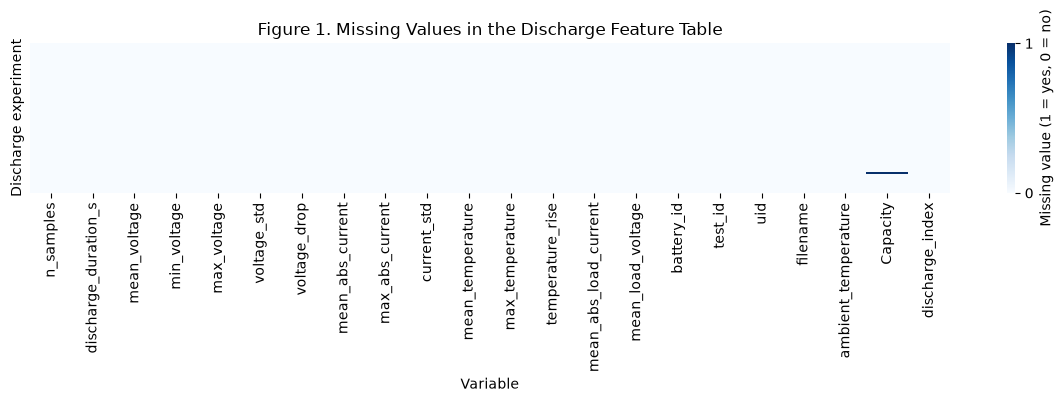

In [15]:
# Figure 1
plt.figure(figsize=(12, 4))
sns.heatmap(
    df.isna(),
    cmap="Blues",
    vmin=0,
    vmax=1,
    yticklabels=False,
    cbar_kws={"label": "Missing value (1 = yes, 0 = no)", "ticks": [0, 1]}
)

plt.title("Figure 1. Missing Values in the Discharge Feature Table")
plt.xlabel("Variable")
plt.ylabel("Discharge experiment")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_1_missing_values_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

The dataset is largely complete, with missing values appearing only in Capacity for 25 discharge experiments (about 0.9% of the data). The small dark region in the heatmap confirms that missingness is sparse rather than widespread across the predictors.

In [16]:
# Duplicate analytical rows
duplicate_count = df.duplicated(
    subset=["battery_id", "test_id", "filename"]
).sum()

print("Duplicate analytical rows:", duplicate_count)

# Basic validity checks
quality_checks = pd.Series({
    "Capacity <= 0": (df["Capacity"] <= 0).sum(),
    "Capacity missing": df["Capacity"].isna().sum(),
    "Duration <= 0": (df["discharge_duration_s"] <= 0).sum(),
    "Too few samples (<5)": (df["n_samples"] < 5).sum()
})
display(quality_checks.to_frame("count"))

Duplicate analytical rows: 0


,count
Capacity <= 0,19
Capacity missing,25
Duration <= 0,0
Too few samples (<5),2


In [17]:
quality_df = df[
    df["Capacity"].notna() &
    (df["Capacity"] > 0) &
    (df["n_samples"] >= 5)
].copy()

outlier_cols = [
    "Capacity",
    "mean_voltage",
    "mean_abs_current",
    "mean_temperature",
    "max_temperature",
    "voltage_drop"
]

outlier_rows = []

for col in outlier_cols:
    s = quality_df[col].dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = ((s < lower) | (s > upper)).sum()

    outlier_rows.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": outlier_count / len(s) * 100
    })

outlier_summary = pd.DataFrame(outlier_rows)

display(outlier_summary)

,feature,lower_bound,upper_bound,outlier_count,outlier_percent
0,Capacity,0.379435,2.451430,195,7.090909
1,mean_voltage,3.182663,3.674712,355,12.909091
2,mean_abs_current,-0.255721,3.265263,206,7.490909
3,mean_temperature,-22.218352,68.293181,0,0.000000
4,max_temperature,-20.441676,80.886786,0,0.000000
5,voltage_drop,-0.570813,2.268190,7,0.254545


The IQR method is used to flag unusually high or low observations in important variables. These values are documented rather than deleted immediately because unusual battery behaviour may be meaningful for degradation analysis.

*Figure 2. Boxplots of Numerical Battery Features*

The boxplots show the spread and potential outliers in numerical measurements, experiment diagnostics and `Capacity` before filtering; identifier columns are excluded. Each panel uses its own scale, and points beyond the whiskers are retained because they may reflect real operating conditions.

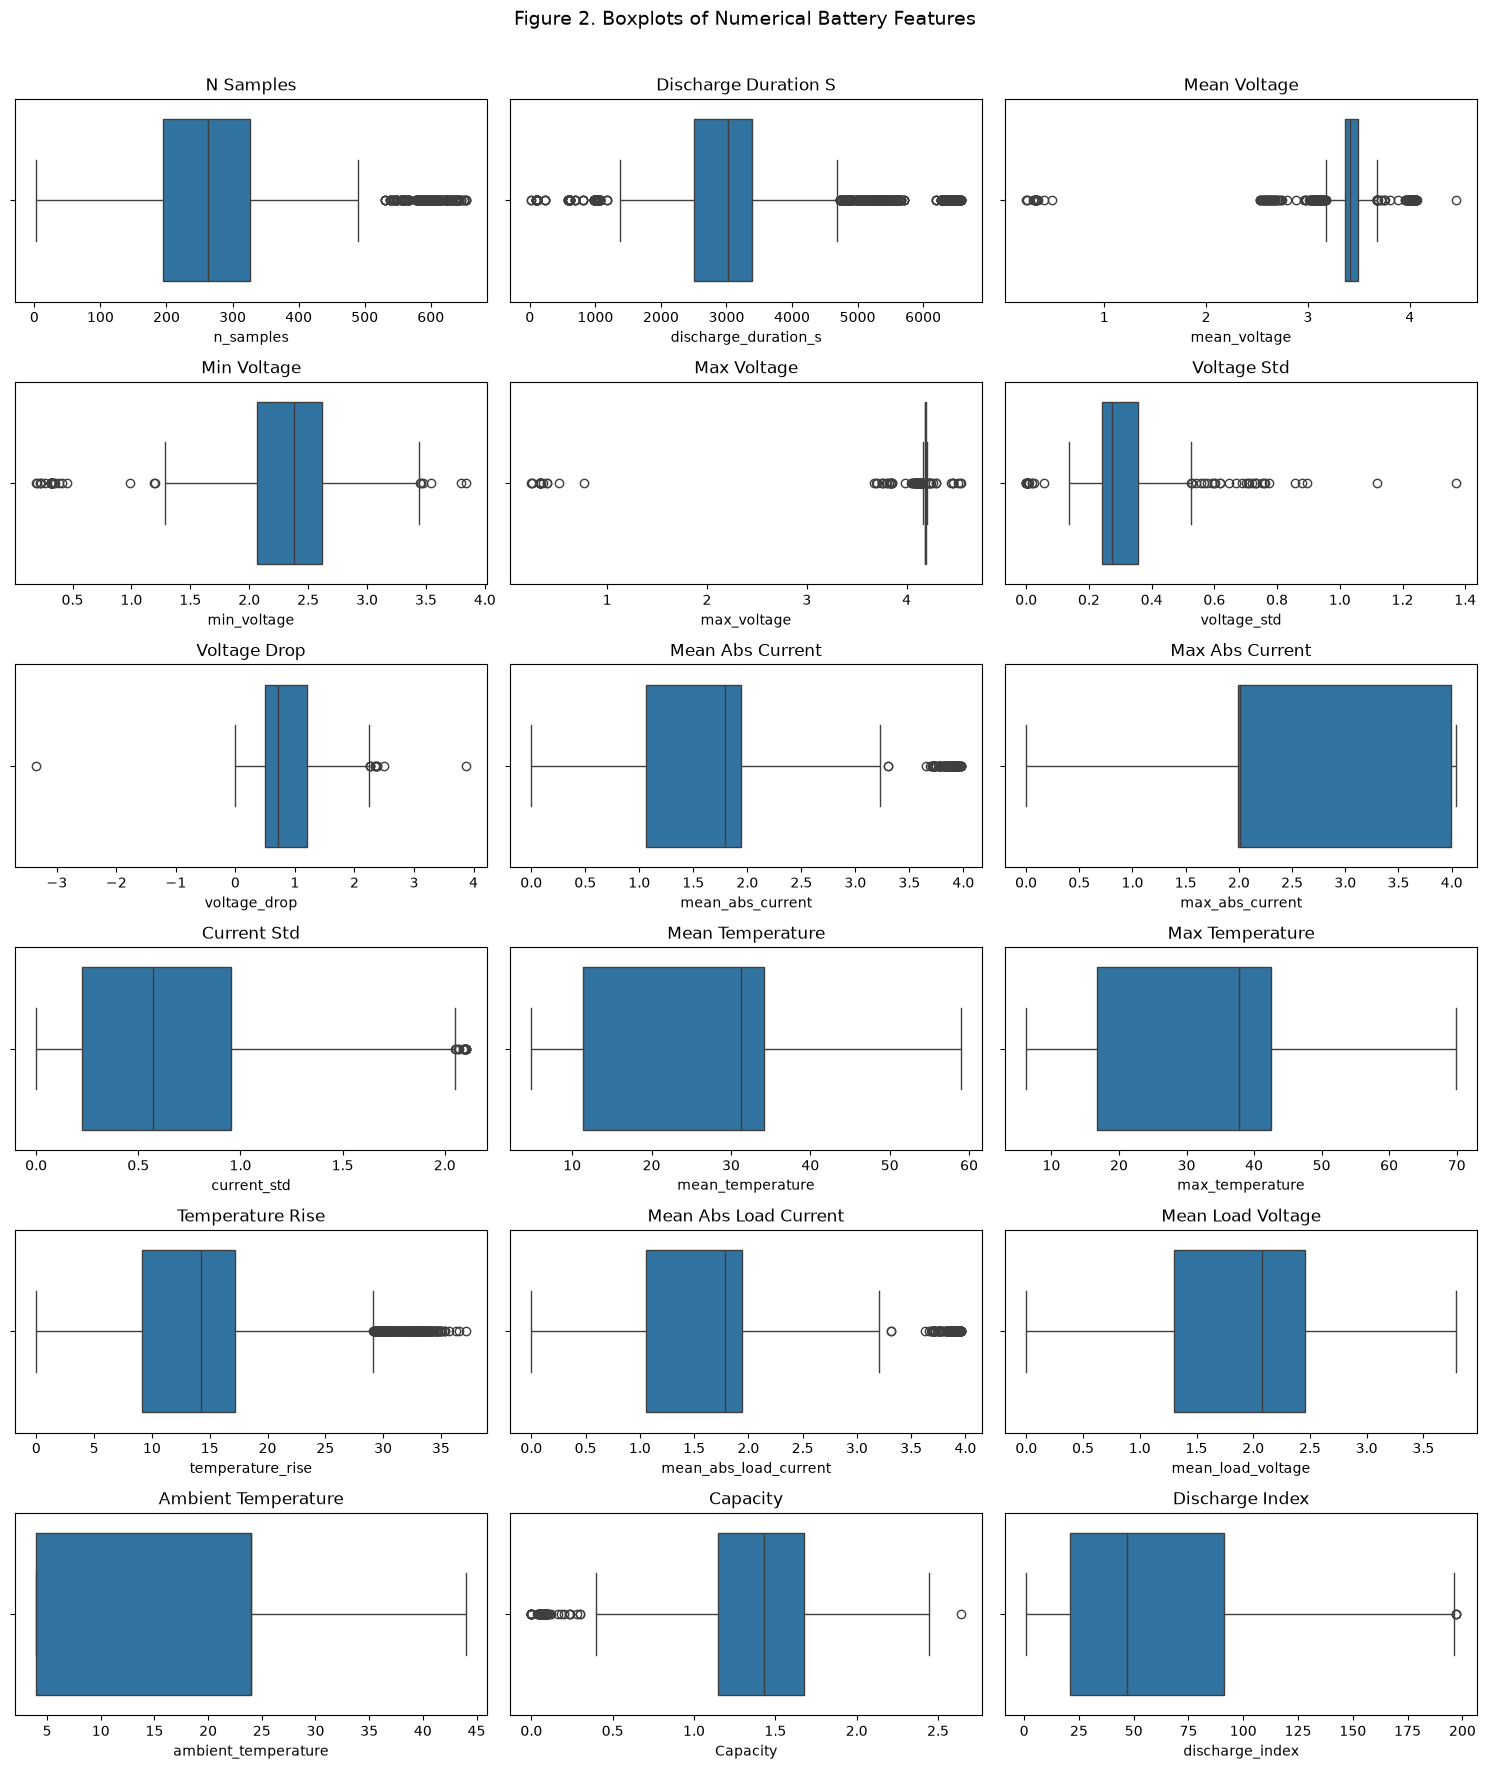

In [18]:
# Figure 2
numeric_cols = (
    df.select_dtypes(include="number")
      .columns.drop(["test_id", "uid"])
      .tolist()
)

n_rows = (len(numeric_cols) + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 3 * n_rows))

for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col)

for ax in axes.ravel()[len(numeric_cols):]:
    ax.set_visible(False)

fig.suptitle("Figure 2. Boxplots of Numerical Battery Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(
    FIG_DIR / "figure_2_numerical_boxplots.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

*Figure 3. IQR Outliers in Selected Variables*

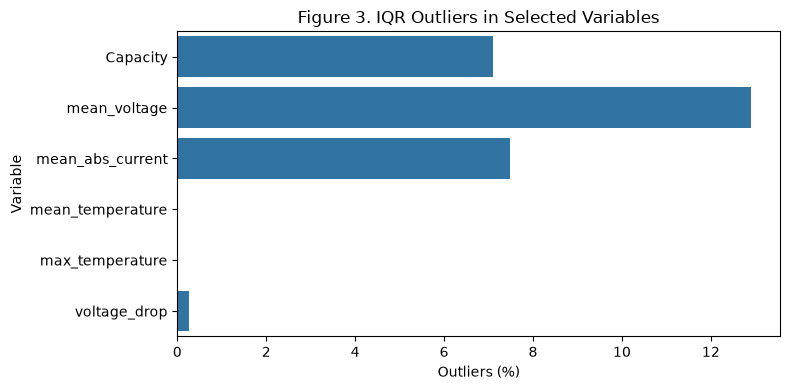

In [19]:
# Figure 3
plt.figure(figsize=(8, 4))

sns.barplot(
    data=outlier_summary,
    x="outlier_percent",
    y="feature"
)

plt.title("Figure 3. IQR Outliers in Selected Variables")
plt.xlabel("Outliers (%)")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_3_iqr_outliers.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Task 3: Target Variable Preparation

### 3.1. Numerical Target Variables

`Capacity` is a continuous measurement in ampere-hours, so the main prediction problem is **regression**. Rows with missing or non-positive Capacity and extremely short experiments are removed, while valid positive observations are retained.

In [20]:
eda_df = df[
    df["Capacity"].notna() &
    (df["Capacity"] > 0) &
    (df["n_samples"] >= 5)
].copy()

eda_df["battery_id"] = eda_df["battery_id"].astype("category")

print("Original shape:", df.shape)
print("EDA shape:", eda_df.shape)

display(eda_df["Capacity"].describe().to_frame().T)

Original shape: (2794, 22)
EDA shape: (2750, 22)


,count,mean,std,min,25%,50%,75%,max
Capacity,2750.000000,1.335708,0.461052,0.032558,1.156433,1.430577,1.674432,2.640149


Very low but positive Capacity measurements are retained because positivity alone does not establish that they are erroneous. Their validity should be interpreted together with battery identity, discharge duration and experimental conditions rather than removed using an arbitrary Capacity threshold.

*Figure 4. Distribution of Numerical Target: Capacity*

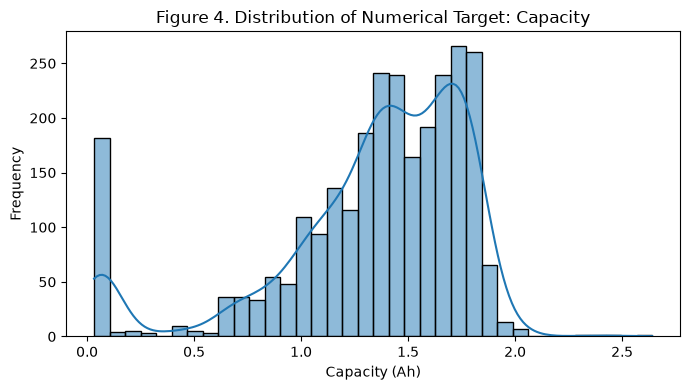

In [21]:
# Figure 4
plt.figure(figsize=(7, 4))

sns.histplot(
    data=eda_df,
    x="Capacity",
    kde=True
)

plt.title("Figure 4. Distribution of Numerical Target: Capacity")
plt.xlabel("Capacity (Ah)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_4_capacity_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### 3.2. Categorical Target Variables

For categorical target analysis, Capacity is divided into `Low`, `Medium`, and `High` groups using tertiles. These approximately balanced classes are used only for descriptive analysis; the original continuous Capacity remains the main modelling target.

In [22]:
eda_df["capacity_class"] = pd.qcut(
    eda_df["Capacity"],
    q=3,
    labels=["Low", "Medium", "High"]
)

display(
    eda_df["capacity_class"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

,count
capacity_class,
Low,917
Medium,916
High,917


The classes are nearly evenly distributed, with High and Low equal and Medium differing by only one observation.

## Task 4: Univariate Analysis

The distributions of key predictors are examined individually to identify their range, spread and possible skewness. Voltage, current, temperature and cycle-related features represent different aspects of battery operation and degradation.

The full set of 15 selected predictors and their summary statistics are shown below. `n_samples` and `discharge_duration_s` remain experiment diagnostics outside this predictor set; identifiers and target-derived `capacity_class` are also excluded.

In [23]:
predictors = [
    "discharge_index",
    "ambient_temperature",
    "mean_voltage",
    "min_voltage",
    "max_voltage",
    "voltage_std",
    "voltage_drop",
    "mean_abs_current",
    "max_abs_current",
    "current_std",
    "mean_temperature",
    "max_temperature",
    "temperature_rise",
    "mean_abs_load_current",
    "mean_load_voltage"
]

print("Summary statistics for all predictors:")
display(eda_df[predictors].describe())

Summary statistics for all predictors:


,discharge_index,ambient_temperature,mean_voltage,min_voltage,max_voltage,voltage_std,voltage_drop,mean_abs_current,max_abs_current,current_std,mean_temperature,max_temperature,temperature_rise,mean_abs_load_current,mean_load_voltage
count,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000,2750.000000
mean,60.928000,18.581818,3.430096,2.314383,4.185638,0.302736,0.898993,1.732180,2.468897,0.769739,27.070622,34.613898,15.086202,1.727531,1.835739
std,48.382245,12.294274,0.198000,0.297389,0.036662,0.083380,0.565566,0.782146,1.104150,0.633729,13.847814,16.275673,8.200265,0.780276,0.854765
min,1.000000,4.000000,2.530010,0.192738,3.677219,0.151614,-0.001175,0.029318,0.996920,0.055684,4.857764,6.935918,1.254512,0.025925,0.043920
25%,22.000000,4.000000,3.367181,2.071735,4.182018,0.242879,0.493813,1.064648,1.993720,0.235799,11.723473,17.556497,9.410269,1.062324,1.339709
50%,48.000000,24.000000,3.415655,2.378529,4.187101,0.274528,0.710897,1.796416,2.014259,0.581501,31.378623,37.912925,14.336454,1.785247,2.080447
75%,91.000000,24.000000,3.490193,2.615707,4.197425,0.356740,1.203564,1.944894,3.992812,0.966160,34.351356,42.888612,17.180641,1.939212,2.456568
max,197.000000,44.000000,4.452558,2.699983,4.542427,1.369938,3.870224,3.976503,4.038796,2.103069,58.954811,69.869746,37.154330,3.957515,3.157976


*Figure 5. Distributions of Key Predictor Variables*

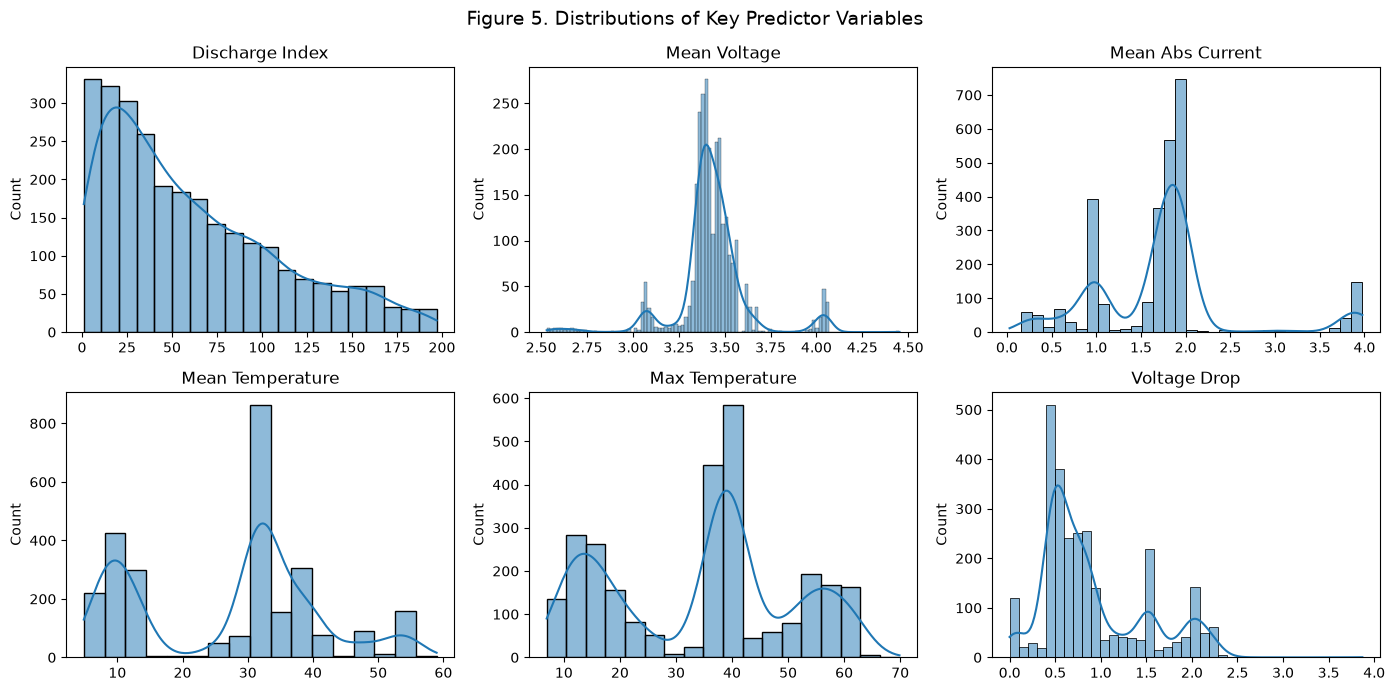

In [24]:
univariate_cols = [
    "discharge_index",
    "mean_voltage",
    "mean_abs_current",
    "mean_temperature",
    "max_temperature",
    "voltage_drop"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(axes.ravel(), univariate_cols):
    sns.histplot(eda_df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")

fig.suptitle(
    "Figure 5. Distributions of Key Predictor Variables",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_5_predictor_distributions.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Several predictors show multimodal rather than single continuous distributions, especially current and temperature measurements. This indicates distinct operating regimes, so differences between observations may reflect both battery ageing and experimental conditions.

The variables also operate on different numerical scales, which should be considered before using scale-sensitive models.

## Task 5: Multivariate Analysis

Correlation analysis is used to examine relationships between `Capacity` and the numerical predictors. Identifier variables are excluded because they do not represent physical battery measurements.

*Figure 6. Correlation Matrix of Battery Features*

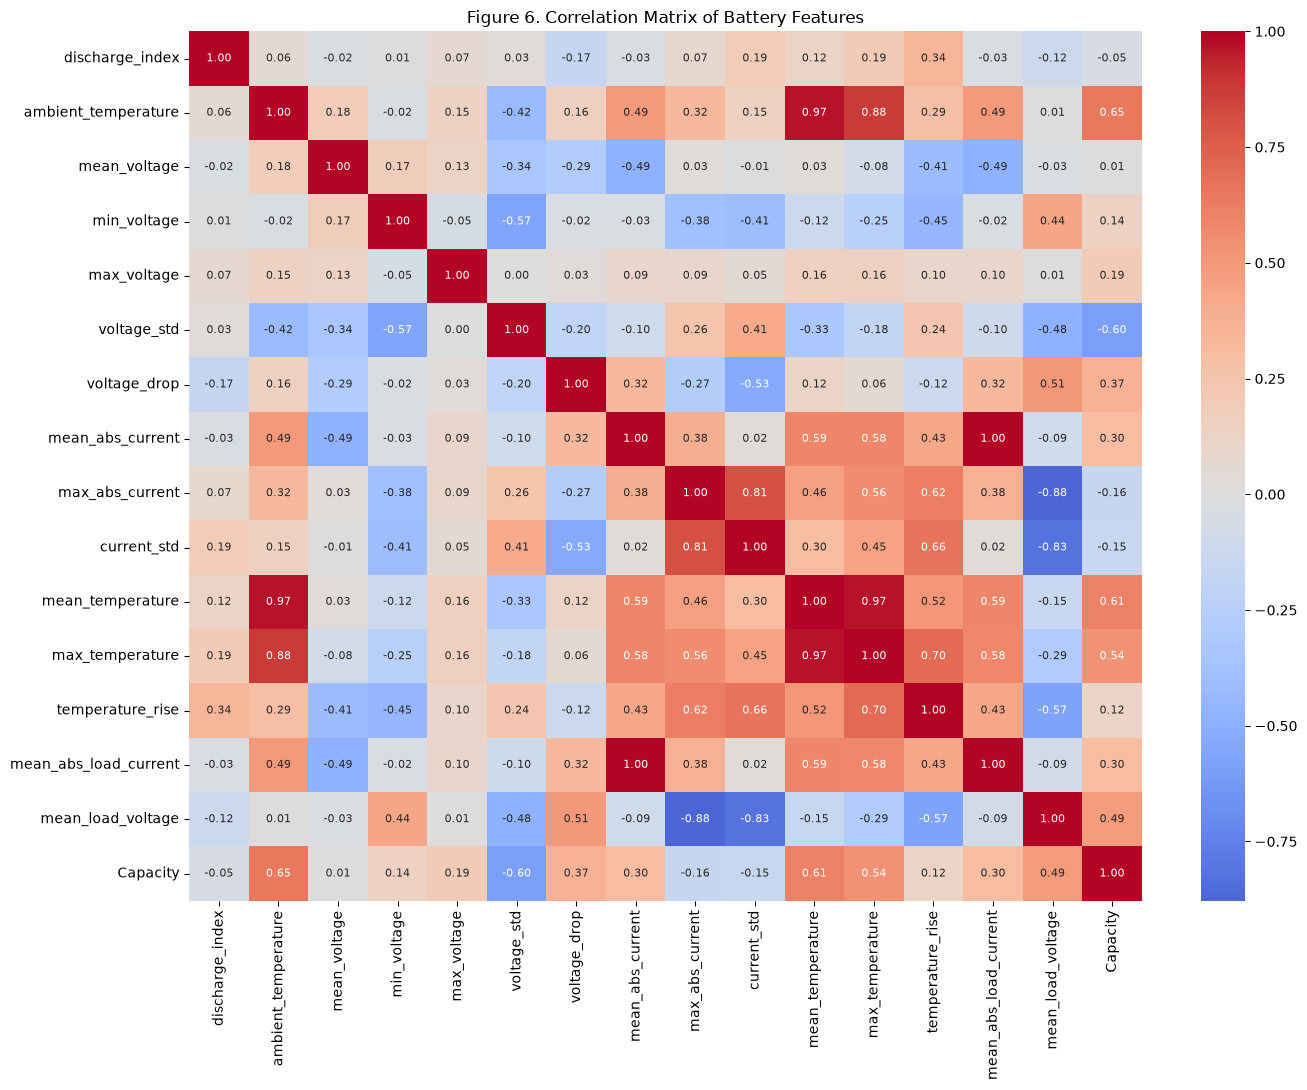

In [25]:
corr = eda_df[predictors + ["Capacity"]].corr(numeric_only=True)

plt.figure(figsize=(14, 11)) 

sns.heatmap(
    corr,
    annot=True,              
    fmt=".2f",              
    annot_kws={"size": 8},   
    cmap="coolwarm",
    center=0
)

plt.title("Figure 6. Correlation Matrix of Battery Features")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_6_correlation_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### Top 3 Features Correlated with `Capacity`

The three strongest Pearson correlations are ranked by absolute magnitude, while their signed coefficients show the direction of association. Correlation is descriptive and does not establish that a feature independently causes Capacity change.

In [26]:
capacity_corr = (
    corr["Capacity"]
    .drop("Capacity")
    .sort_values(key=abs, ascending=False)
)

print("Top 3 features correlated with Capacity (Pearson r):")
display(capacity_corr.head(3).to_frame("correlation"))

# Strong predictor-predictor correlations indicate redundant information
predictor_corr = eda_df[predictors].corr(numeric_only=True).abs()
upper = predictor_corr.where(
    np.triu(np.ones(predictor_corr.shape), k=1).astype(bool)
)

strong_pairs = (
    upper.stack()
         .sort_values(ascending=False)
         .rename("abs_correlation")
         .reset_index()
         .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

display(strong_pairs[strong_pairs["abs_correlation"] >= 0.90].head(10))

Top 3 features correlated with Capacity (Pearson r):


,correlation
ambient_temperature,0.651071
mean_temperature,0.607846
voltage_std,-0.597654


,feature_1,feature_2,abs_correlation
0,mean_abs_current,mean_abs_load_current,0.999915
1,mean_temperature,max_temperature,0.969693
2,ambient_temperature,mean_temperature,0.965445


Temperature-related variables rank among the strongest associations with Capacity, but several are also highly correlated with one another. Likewise, measured current and load current describe closely related electrical behaviour. Future modelling should avoid treating highly redundant measurements as independent information.

*Figure 7. Pairplot of the Top 3 Correlated Features and Capacity*

The pairplot compares `Capacity` with the three predictors having the strongest absolute correlations, with histograms on the diagonal. The temperature variables are related to one another, so their associations with Capacity should not be treated as independent effects.

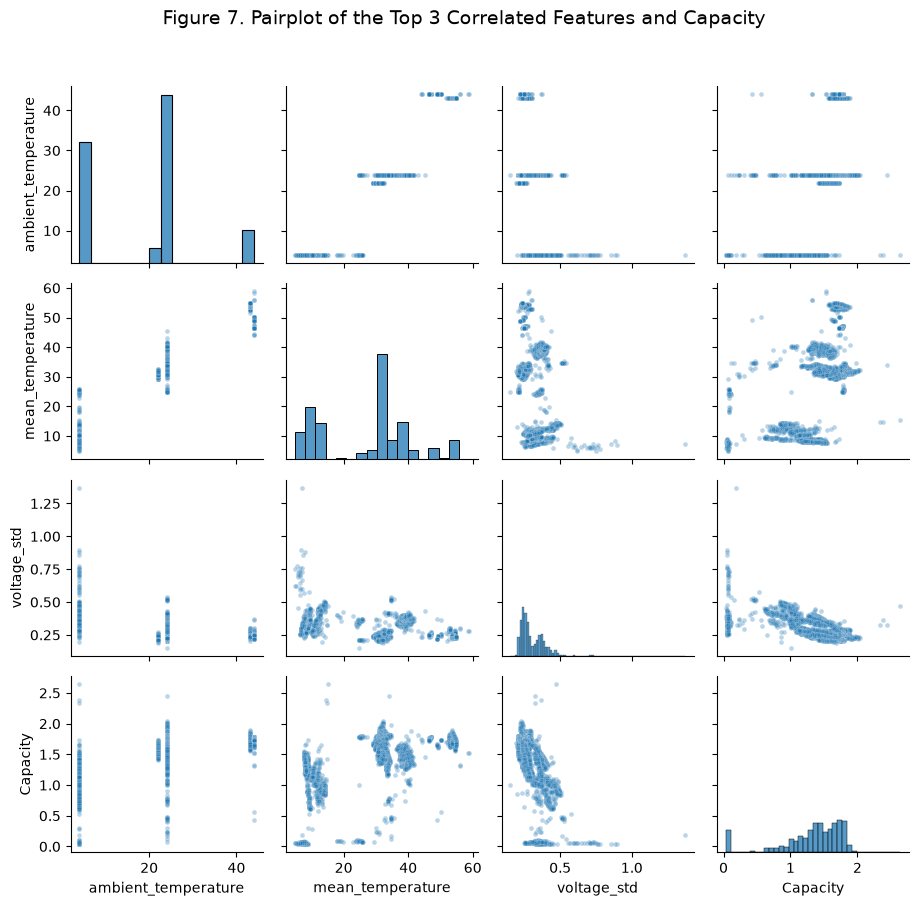

In [27]:
# Figure 7
pairplot_cols = capacity_corr.head(3).index.tolist() + ["Capacity"]

g = sns.pairplot(
    data=eda_df[pairplot_cols],
    diag_kind="hist",
    plot_kws={"alpha": 0.3, "s": 12},
    height=2.3
)

g.fig.suptitle(
    "Figure 7. Pairplot of the Top 3 Correlated Features and Capacity",
    fontsize=14
)
g.fig.tight_layout(rect=[0, 0, 1, 0.95])

g.savefig(
    FIG_DIR / "figure_7_capacity_pairplot.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

*Figure 8. Capacity vs Discharge Cycle Index*

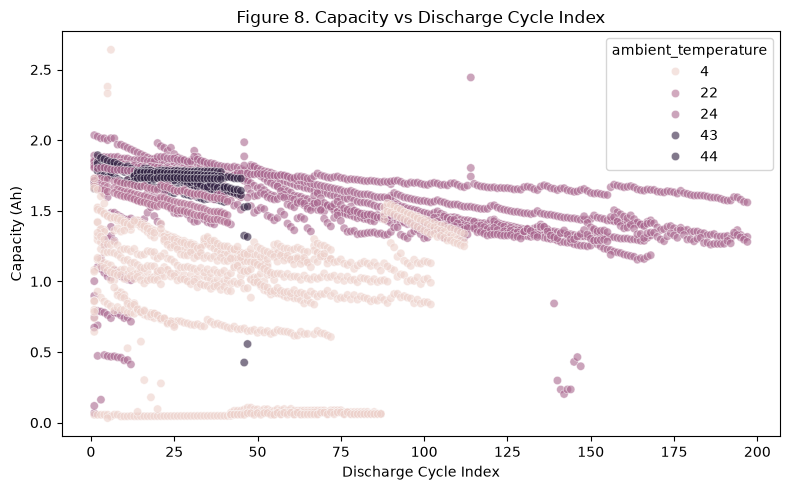

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=eda_df,
    x="discharge_index",
    y="Capacity",
    hue="ambient_temperature",
    alpha=0.6
)

plt.title("Figure 8. Capacity vs Discharge Cycle Index")
plt.xlabel("Discharge Cycle Index")
plt.ylabel("Capacity (Ah)")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_8_capacity_vs_cycle.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

The pooled relationship between discharge order and Capacity is weak because observations from different batteries and operating conditions overlap. Distinct groups are visible across temperature and battery conditions, so ageing is more meaningfully assessed within individual batteries than across all discharge records pooled together.

In [29]:
battery_discharge_corr = pd.Series({
    battery: group["discharge_index"].corr(
        group["Capacity"],
        method="spearman"
    )
    for battery, group in eda_df.groupby("battery_id", observed=True)
}, name="discharge_index_capacity_correlation")

display(battery_discharge_corr.describe().to_frame())

,discharge_index_capacity_correlation
count,34.000000
mean,-0.650935
std,0.431636
min,-0.993382
25%,-0.940615
50%,-0.818063
75%,-0.570966
max,0.689999


Battery-specific correlations separate within-battery ageing behaviour from differences between batteries. This is important because the thousands of discharge rows are repeated measurements from only a few dozen physical batteries, not thousands of independent battery samples.

## Task 6: Engineering Interpretation

Battery degradation should be interpreted as a repeated-cycle process rather than as isolated measurements. Comparing battery trajectories shows how usable capacity changes over successive discharge cycles and whether degradation patterns differ between individual batteries.

*Figure 9. Capacity Degradation Across Battery Cycles*

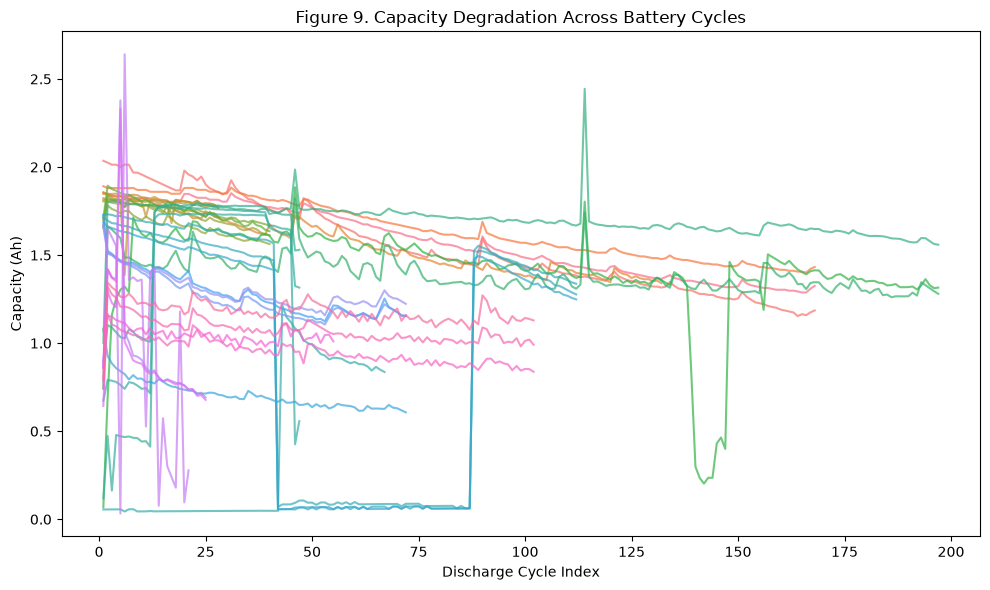

In [30]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=eda_df,
    x="discharge_index",
    y="Capacity",
    hue="battery_id",
    estimator=None,
    alpha=0.7,
    legend=False
)

plt.title("Figure 9. Capacity Degradation Across Battery Cycles")
plt.xlabel("Discharge Cycle Index")
plt.ylabel("Capacity (Ah)")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_9_capacity_degradation.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Many battery trajectories show an overall reduction in usable Capacity, which is consistent with ageing. However, abrupt drops and spikes also occur, indicating that measured Capacity is influenced by test protocol, load, temperature or unusual runs in addition to irreversible degradation.

Therefore, every short-term decrease in Capacity should not automatically be interpreted as permanent battery ageing.

*Figure 10. Capacity Distribution by Ambient Temperature*

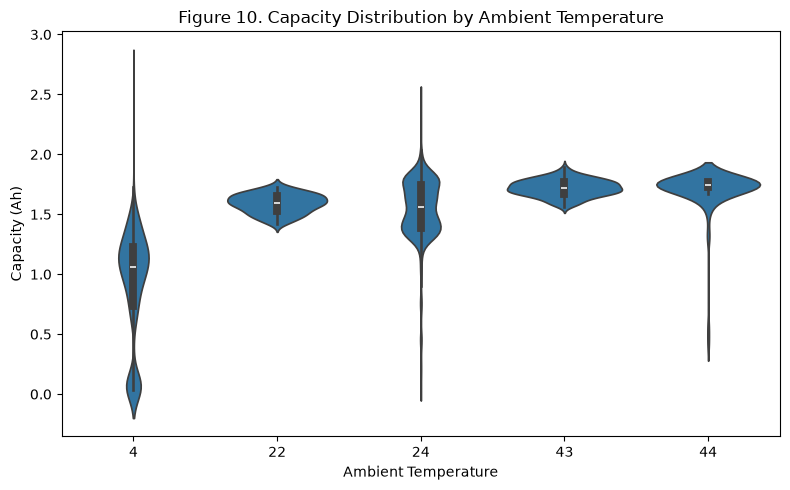

In [31]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=eda_df,
    x="ambient_temperature",
    y="Capacity"
)

plt.title("Figure 10. Capacity Distribution by Ambient Temperature")
plt.xlabel("Ambient Temperature")
plt.ylabel("Capacity (Ah)")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_10_capacity_by_temperature.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Capacity distributions differ substantially across ambient-temperature conditions. The lower-temperature experiments show reduced usable Capacity, which is consistent with slower lithium-ion reaction kinetics and greater polarization at low temperature.

However, the temperature groups also contain different batteries and test conditions. The figure therefore shows an association with operating condition rather than proving that temperature alone causes the Capacity difference. Short-term available capacity and long-term ageing effects should also be distinguished.

### Engineering Interpretation Questions

**What do the correlations mean in engineering terms?**  
`Capacity` is positively correlated with ambient temperature (r ≈ 0.651) and mean battery temperature (r ≈ 0.608), while voltage variability has a negative correlation (r ≈ −0.598). These associations link delivered charge to thermal conditions and discharge-voltage behaviour, but different batteries and protocols are mixed together, so they do not isolate causal effects.

**Are there any unexpected patterns from an engineering perspective?**  
The pooled correlation between `discharge_index` and `Capacity` is weak (r ≈ −0.048), despite the ageing trends visible within many batteries. Abrupt capacity drops and spikes also depart from smooth degradation, and the source notes report some very low-capacity runs whose causes remain unresolved.

**What physical/process relationships do the data reflect?**  
Discharge capacity reflects current delivered over time, while voltage and temperature trajectories reflect the load and the battery's electrical and thermal response. Reduced usable capacity in cold tests is consistent with slower reaction kinetics and greater polarization, whereas longer-term capacity decline is consistent with ageing; the observed correlations cannot separate these effects by themselves.

**Are there important missing features that could improve future modelling?**  
Rest duration, cumulative charge throughput and explicit per-test load and cutoff settings would help distinguish usage history from operating conditions; these are absent from the current feature table and would need to be derived or assembled. Impedance measurements, including `Re` and `Rct`, are already available in the source data but unused here, and could be linked using only measurements available before the prediction time.

## Task 7: Challenges Encountered

The dataset contains thousands of separate experiment files rather than a single analysis-ready table, and it mixes charge, discharge and impedance tests. Discharge files therefore had to be selected and converted from variable-length sensor sequences into one row per experiment.

*Figure 11. Number of Sensor Samples per Discharge Experiment*

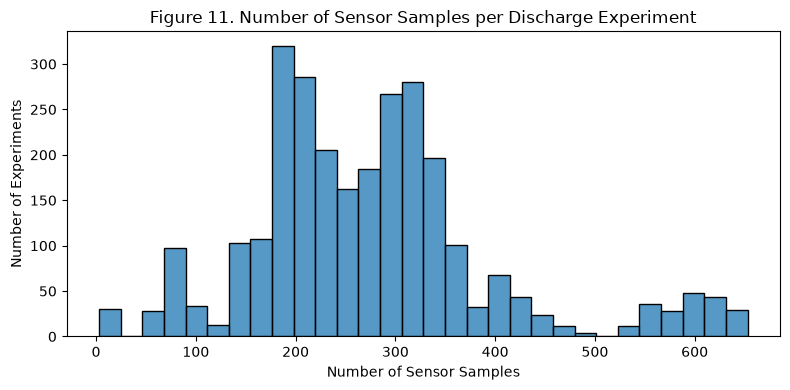

In [32]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="n_samples",
    bins=30
)

plt.title("Figure 11. Number of Sensor Samples per Discharge Experiment")
plt.xlabel("Number of Sensor Samples")
plt.ylabel("Number of Experiments")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_11_samples_per_experiment.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

Discharge files contain different numbers of sensor samples, so the raw time series are not uniform in length. Feature aggregation makes them comparable for this EDA; a future sequence model would instead require an explicit strategy such as alignment, resampling, padding or masking.

## Task 8: Responsible AI Reflection Questions

Poor data quality can reduce model reliability because missing, incorrect or noisy sensor measurements may produce inaccurate engineered features. A model could then learn measurement artefacts instead of genuine battery degradation patterns.

The main bias concern is experimental bias rather than demographic bias. Different batteries and operating conditions may not be equally represented, so a model trained on this dataset may not generalise to other battery chemistries, manufacturers or environments.

*Figure 12. Number of Discharge Experiments per Battery*

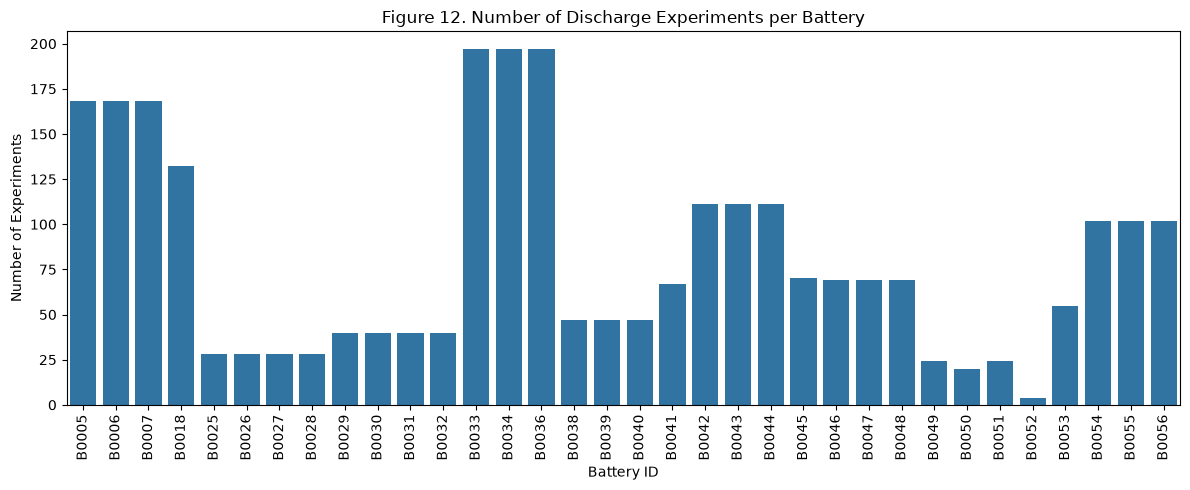

In [33]:
battery_counts = (
    eda_df["battery_id"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

sns.barplot(
    x=battery_counts.index.astype(str),
    y=battery_counts.values
)

plt.title("Figure 12. Number of Discharge Experiments per Battery")
plt.xlabel("Battery ID")
plt.ylabel("Number of Experiments")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    FIG_DIR / "figure_12_experiments_per_battery.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

The number of observations varies between batteries, and the cleaned table contains repeated measurements from only 34 physical batteries. A random row-level train/test split could therefore place observations from the same battery in both sets and overestimate model performance.

Future modelling should use battery-aware validation such as `GroupKFold` or leave-battery-out evaluation. Results should also not be assumed to generalise automatically to different cell chemistries, manufacturers or operating environments.

### Temporal Leakage Consideration

Several engineered predictors use information from the complete discharge experiment, while `Capacity` is measured from that same experiment. These variables are suitable for EDA, but a true early battery-health prediction system should use only information available before the target discharge or from a clearly defined early portion of the signal.

## Task 9: Summary Report

The EDA converts individual discharge time series into an analysis-ready table of electrical, thermal and operational features with `Capacity` as the main regression target. The results show that Capacity reflects both longitudinal battery ageing and experimental operating conditions, so pooled correlations must be interpreted cautiously.

For future modelling, the main engineering requirements are battery-aware validation, control of highly correlated predictors, consistent treatment of operating conditions and prevention of temporal leakage.

The final cleaned dataset and supporting figures are saved in the local `output/` folder for use in the Portfolio Assessment report.

The report is submitted to Canvas as `Portfolio_Assessment_1_Le_Mai_Chi.pdf`.

In [34]:
eda_df.to_csv(CLEAN_DATA_PATH, index=False)

summary = pd.DataFrame({
    "Item": [
        "Original discharge records",
        "Final EDA records",
        "Number of batteries",
        "Candidate predictor variables",
    ],
    "Value": [
        len(df),
        len(eda_df),
        eda_df["battery_id"].nunique(),
        len(predictors),
    ]
})

display(summary)

# print("Clean dataset:", CLEAN_DATA_PATH)
# print("Figures:", FIG_DIR)

,Item,Value
0,Original discharge records,2794
1,Final EDA records,2750
2,Number of batteries,34
3,Candidate predictor variables,15
